In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt
from PIL import Image
from matplotlib.ticker import FuncFormatter

# Figure 1

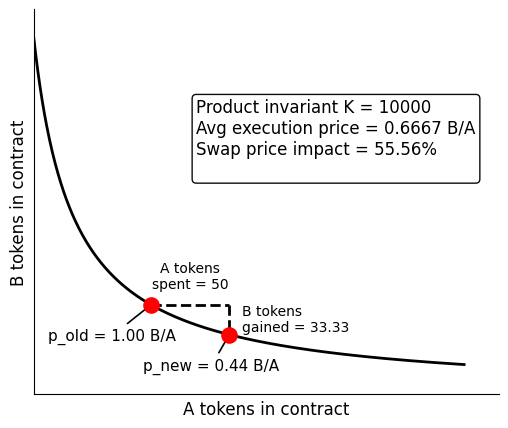

In [ ]:
def trade_spend_A_gain_B(x0, y0, dA):
    k = x0 * y0
    x1 = x0 + dA
    y1 = k / x1
    dB_out = y0 - y1
    return x1, y1, dB_out

# --- parameters (edit) ---
x0, y0 = 100.0, 100.0     # old position (reserves)
dA = 50                 # A tokens spent into pool (user input)

x1, y1, dB_out = trade_spend_A_gain_B(x0, y0, dA)
k = x0 * y0

# Prices + slippage
p_old = y0 / x0                 # spot: B per A
p_new = y1 / x1                 # spot after trade
avg_price = dB_out / dA         # average execution (B per A)
slip_spot = (p_old - p_new) / p_old          # spot-price impact (fraction)
slip_avg  = (p_old - avg_price) / p_old      # vs average execution (fraction)

# Curve domain
x_min = max(1e-6, x0 * 0.25)
x_max = max(x1 * 2.0, x0 * 2.0)
X = np.linspace(x_min, x_max, 600)
Y = k / X

fig, ax = plt.subplots(figsize=(6, 5))

# Invariant curve
ax.plot(X, Y, color="black", lw=2)

# Old/New points (red dots)
ax.scatter([x0, x1], [y0, y1], s=120, color="red", zorder=5)

# "L" shaped path: horizontal then vertical
ax.plot([x0, x1], [y0, y0], color="black", linestyle="--", lw=2)
ax.plot([x1, x1], [y0, y1], color="black", linestyle="--", lw=2)

# # Labels near points
# ax.text(x0 - 0.18*(x_max-x_min), y0, f"p_old = {p_old:.4f} B/A", ha="left", va="center", fontsize=12)
# ax.text(x1 - 0.07*(x_max-x_min), y1 - 0.06*(Y.max()-Y.min()), f"p_new = {p_new:.4f} B/A",
#         ha="center", va="top", fontsize=12)

# Trade annotations
mid_x = (x0 + x1) / 2
ax.text(mid_x, y0 + 0.04*(Y.max()-Y.min()), f"A tokens\nspent = {dA}", ha="center", va="bottom", fontsize=10)

mid_y = (y0 + y1) / 2
ax.text(x1 + 0.03*(x_max-x_min), mid_y, f"B tokens\ngained = {dB_out:.2f}", ha="left", va="center", fontsize=10)

# --- Price annotations at old/new + slippage ---
# Place text slightly offset from each point
dx = 0.04 * (x_max - x_min)
dy = 0.06 * (Y.max() - Y.min())

ax.annotate(f"p_old = {p_old:.2f} B/A",
            xy=(x0, y0), xytext=(x0 - 6*dx, y0 - 2*dy),
            textcoords="data",
            arrowprops=dict(arrowstyle="-", lw=1.2, color="black"),
            fontsize=11, ha="left", va="bottom")

ax.annotate(f"p_new = {p_new:.2f} B/A",
            xy=(x1, y1), xytext=(x1 - 5*dx, y1 - 2*dy),
            textcoords="data",
            arrowprops=dict(arrowstyle="-", lw=1.2, color="black"),
            fontsize=11, ha="left", va="bottom")

# Slippage summary box (spot impact + average execution)
slip_text = (
    f"Product invariant K = {int(k):02d}\n"
    f"Avg execution price = {avg_price:.4f} B/A
    f"Swap price impact = {slip_spot*100:.2f}%\n"
)
ax.text(0.35, 0.57, slip_text, transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.95))

# Axis labels like the reference
ax.set_xlabel("A tokens in contract", fontsize=12)
ax.set_ylabel("B tokens in contract", fontsize=12)

# Clean diagram look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Nice limits with padding
pad_x = 0.08 * (x_max - x_min)
pad_y = 0.08 * (Y.max() - Y.min())
ax.set_xlim(x_min, x_max + pad_x)
ax.set_ylim(0, Y.max() + pad_y)

plt.savefig('invariant_with_slippage.png', dpi=300, transparent = True, bbox_inches='tight')

# Figure 2

## a.

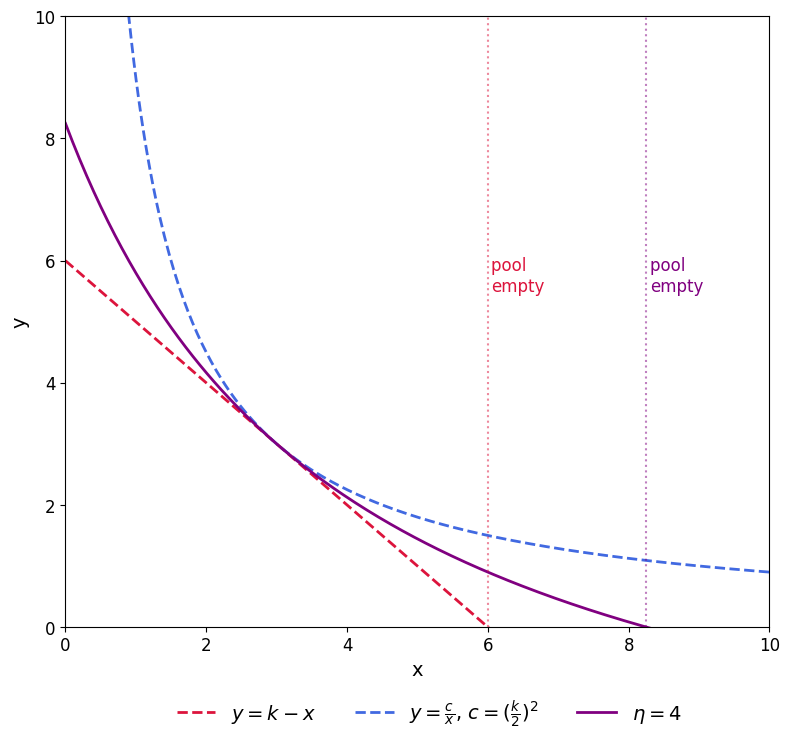

In [47]:
fig, axs = plt.subplots(1, 1, figsize=(8, 7))
x = np.linspace(0.001, 10, 300)

k = 6
A = 4
c = (k/2)**2  # adjust CP so equilibrium is at (k/2, k/2)

# --- curves (y vs x) ---
y_sum  = k - x
y_prod = c / x
y_crv  = (A*k + c - A*x) / (A + x)


axs.set_xlim((0, 10))
axs.set_ylim((0, 10))

# left subplot: state curves
axs.plot(x, y_sum,  color="crimson",   linestyle="--", label=r"$y=k-x$", lw = 2)
axs.plot(x, y_prod, color="royalblue", linestyle="--", label=r"$y=\frac{c}{x}$, $c=( \frac{k}{2})^2$", lw = 2)
axs.plot(x, y_crv,  color="purple",                 label=r"$\eta = 4$", lw = 2)
# axs.set_title("Invariant curves")
axs.set_ylabel("y", fontsize = 14)
axs.set_xlabel("x", fontsize = 14)
# axs[0].legend()

# --- prices (tangent): p = -dy/dx ---
p_sum  = np.ones_like(x)
p_prod = c / x**2
p_crv  = (A**2 + A*k + c) / (A + x)**2  # from analytic derivative of y_crv

# Add annotations where pool can empty (y=0)
x_sum_empty = k  # where y_sum = 0
x_crv_empty = (A*k + c) / A  # where y_crv = 0

axs.axvline(x=x_sum_empty, color="crimson", linestyle=":", alpha=0.5, linewidth=1.5)
axs.axvline(x=x_crv_empty, color="purple", linestyle=":", alpha=0.5, linewidth=1.5)
axs.text(x_sum_empty+ 0.05, 5.5, "pool \nempty", color="crimson", fontsize=12, ha="left")
axs.text(x_crv_empty+ 0.05, 5.5, "pool \nempty", color="purple", fontsize=12, ha="left")
axs.tick_params(labelsize=12)

# right subplot: price curves

# axs[0].legend(frameon = False)
# axs[1].legend(frameon = False)
handles, labels = axs.get_legend_handles_labels()
fig.legend(handles, labels, ncols = 3, frameon = False, bbox_to_anchor = (0.88,0.02), fontsize =14)

plt.tight_layout()
plt.savefig('constant_sum_product_curve', transparent = True, dpi = 300, bbox_inches = 'tight')

## b.

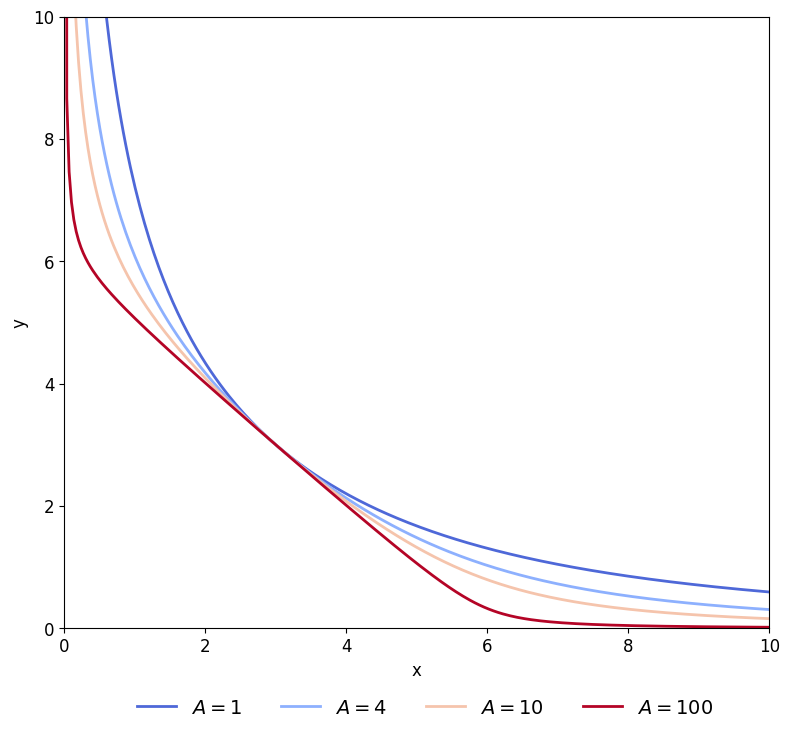

In [52]:
fig, axs = plt.subplots(1, 1, figsize=(8, 7))
x = np.linspace(0.0001, 10, 300)

k = 6
c = (k/2)**2  # adjust CP so equilibrium is at (k/2, k/2)




axs.set_xlim((0, 10))
axs.set_ylim((0, 10))

for A in [1, 4, 10, 100]:
    # y = np.sqrt((x - k + k**2/4*A)**2 + k**4 / (4*A*x) ) - (x - k + k**2 / 4*A)
    y = (1/2) * (np.sqrt((x + k **2 /(4*A) - k)**2 + k ** 4/ (4*A*x)) - (x + k ** 2 /(4*A) - k))
    axs.plot(x, y,  color=mpl.colormaps['coolwarm'](A/16),label=r"$A = {}$".format(A), lw = 2)
# axs.set_title("Invariant curves", fontsize = 14)
axs.set_ylabel("y", fontsize = 12)
axs.set_xlabel("x", fontsize = 12)
# axs[0].legend()
axs.tick_params(labelsize=12)

handles, labels = axs.get_legend_handles_labels()
fig.legend(handles, labels, ncols = 4, frameon = False, bbox_to_anchor = (0.92,0.02), fontsize = 14)

plt.tight_layout()
plt.savefig('stableswap_invariant_curves', transparent = True, dpi = 200, bbox_inches = 'tight')

# Figure 3

## a.

In [8]:
def get_D(xp, A, n_iter=256):
    n = len(xp)
    S = sum(xp)
    if S == 0:
        return 0.0
    D = S
    Ann = A * n
    for _ in range(n_iter):
        D_prev = D
        D_P = D
        for x in xp:
            D_P = D_P * D / (x * n)
        D = (Ann * S + D_P * n) * D / ((Ann - 1) * D + (n + 1) * D_P)
        if abs(D - D_prev) <= 1e-12 * D:
            break
    return D
def curve_spot_price(x, D, A, eps=1e-6):
    y1 = get_y(x, D, A)
    y2 = get_y(x * (1.0 + eps), D, A)
    dy_dx = (y2 - y1) / (x * eps)
    return -dy_dx
    
def get_y(x, D, A, n_iter=256):
    n = 2
    Ann = A * n
    c = D
    S_ = x
    c = c * D / (x * n)
    c = c * D / (Ann * n)
    b = S_ + D / Ann

    y = D
    for _ in range(n_iter):
        y_prev = y
        y = (y * y + c) / (2 * y + b - D)
        if abs(y - y_prev) <= 1e-12 * y:
            break
    return y

def curve_effective_liquidity_vs_price(A, x0=1.0, y0=1.0,
                                       P_min=0.98, P_max=1.02,
                                       x_min=0.2, x_max=5.0,
                                       n_x=2000, n_P=400):
    
    D = get_D([x0, y0], A)


    xs = np.logspace(np.log10(x_min), np.log10(x_max), n_x)
    Ps = np.array([curve_spot_price(x, D, A) for x in xs])

    idx = np.argsort(Ps)
    Ps_sorted = Ps[idx]
    xs_sorted = xs[idx]

    P_grid = np.linspace(P_min, P_max, n_P)
    x_of_P = np.interp(P_grid, Ps_sorted, xs_sorted)

    lnP = np.log(P_grid)
    L_eff = np.abs(np.gradient(x_of_P, lnP))
    return P_grid, L_eff


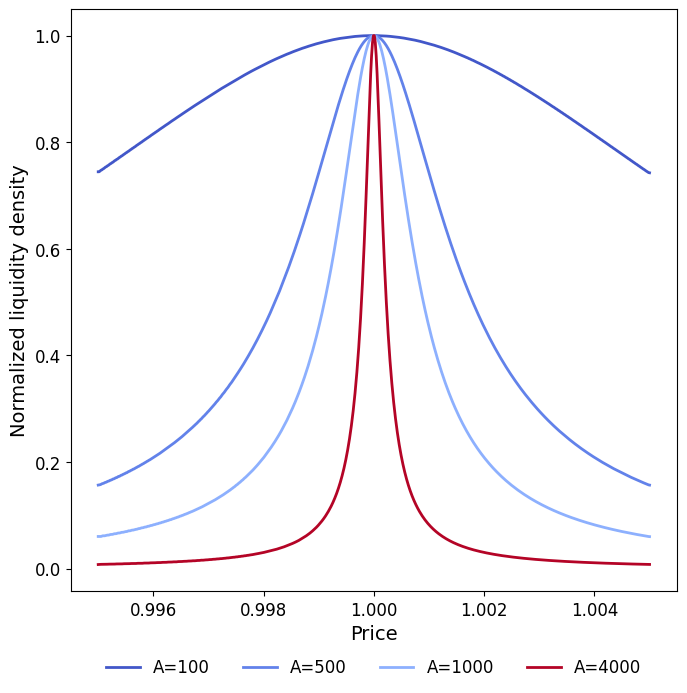

In [21]:
P_min, P_max = 0.995, 1.005
P_grid = np.linspace(P_min, P_max, 600)

fig, ax = plt.subplots(1,1, figsize=(7, 7))

# Curve: implied smooth "distribution" controlled by A
for A in [100, 500, 1000, 4000]:
    P, L_eff = curve_effective_liquidity_vs_price(
        A=A, x0=1.0, y0=1.0, P_min=P_min, P_max=P_max,
        x_min=0.1, x_max=5.0, n_x=3000, n_P=len(P_grid)
    )
    L_eff = L_eff / L_eff.max()  # normalize to compare shapes
    ax.plot(P, L_eff, linewidth=2, label=f"A={A}", color = mpl.colormaps['coolwarm'](A/4000))

ax.tick_params(labelsize=12)
ax.set_xlabel("Price", fontsize=14)
ax.set_ylabel("Normalized liquidity density", fontsize=14)
ax.legend(ncols = 4, frameon = False, bbox_to_anchor= (0.5,-0.09), loc = 'upper center', fontsize=12)
plt.tight_layout()
plt.savefig('curve_liquidity_paper', dpi = 300, transparent = True, bbox_inches = 'tight')

## b.

In [19]:
def plot_liq(df_day, hour, ax, show = True):
    df_day = df_day[df_day['hour'] == hour].sort_values(by='priceMid')
    x = df_day['priceMid'].values
    w = np.diff(x).min() * 0.8 
    ax.bar(x, df_day['usd_token0'], width =w, label = 'USDC', color = "cornflowerblue")
    ax.bar(x, df_day['usd_token1'], width =w, label = 'USDT', color = "mediumaquamarine")
    ax.axvline(1, color = 'black')
    ax.axvline(df_day.query('usd_token0 > 0')['priceMid'].values[0], color = 'grey', linestyle = '--', label = 'active tick')
    # plt.bar(x, df_day['usd_total'], width =w)
    ax.set_xlabel('USDC price')
    ax.set_ylabel('tick liquiditiy ($)')
    ax.legend(frameon = False, bbox_to_anchor= (0.62,-0.1), ncols = 3)

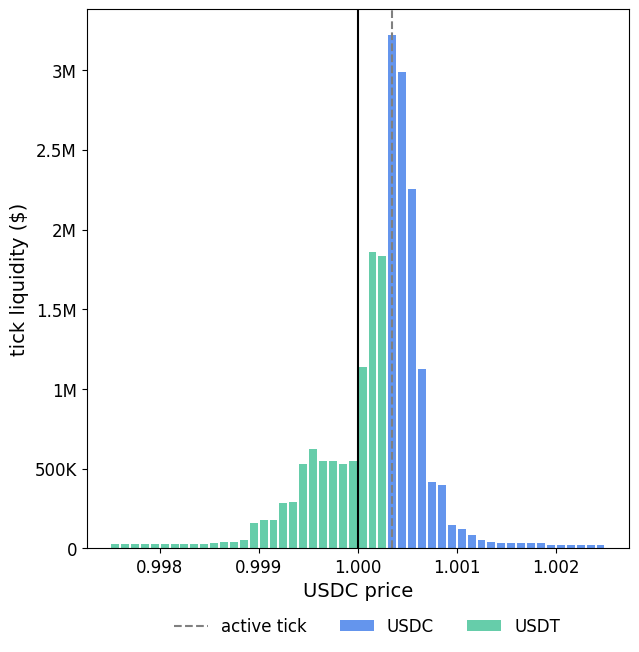

In [20]:
df = pd.read_parquet('./data/Uniswap/hourly_liquidity_full.parquet')

hours = np.array(sorted(df["hour"].unique()))
fig, ax = plt.subplots(1,1, figsize = (7,7))
window = 25
plot_liq(df.query('tickLower >= -@window and tickUpper <= @window'), hours[-1], ax)
def human_format(x, pos=None):
    x = float(x)
    absx = abs(x)
    if absx >= 1_000_000:
        val = x / 1_000_000
        return f"{val:g}M" if val % 1 else f"{int(val)}M"
    if absx >= 1_000:
        val = x / 1_000
        return f"{val:g}K" if val % 1 else f"{int(val)}K"
    return f"{x:g}"
ax.yaxis.set_major_formatter(FuncFormatter(human_format))
ax.set_xlabel('USDC price', fontsize=14)
ax.set_ylabel('tick liquidity ($)', fontsize=14)
ax.legend(frameon = False, bbox_to_anchor= (0.9,-0.1), ncols = 3, fontsize=12)
ax.tick_params(labelsize=12)

plt.savefig('uniswap_liquidity_paper.png', dpi = 300, transparent = True, bbox_inches = 'tight')

# Figure 4

## a. 

In [62]:
df = pd.read_parquet("./data/Uniswap/USDC_USDT_hourly_metrics.parquet").query('feeTier == 100')
df.index = df['datetime']

In [82]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

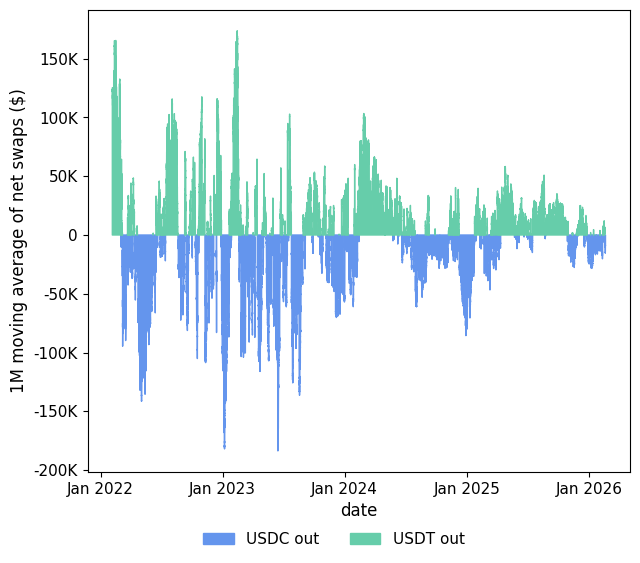

In [98]:
plotdf = df[['net_amount0']] 
plotdf.index = df['datetime'] 
t= plotdf['net_amount0'].rolling(24*7*5).mean().dropna() 
fig, ax = plt.subplots(figsize = (7,6)) 
ax.fill_between(t.index, 0, t, where=t<0, color = 'cornflowerblue', label ='USDC out') 
ax.fill_between(t.index, 0, t, where=t>=0,  color = 'mediumaquamarine', label ='USDT out') 
ax.tick_params(labelsize = 11)
locator = mdates.AutoDateLocator(minticks=3, maxticks=5)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y", tz=mdates.UTC)) 
ax.yaxis.set_major_formatter(FuncFormatter(human_format)) 
ax.set_xlabel('date', fontsize = 12) 
ax.legend(ncols = 2, frameon = False, bbox_to_anchor =(.72,-0.1), fontsize = 11) 
ax.set_ylabel('1M moving average of net swaps ($)', fontsize = 12) 
plt.savefig('./Net_swap_hourly_SMA.png', dpi = 300, transparent = True, bbox_inches = 'tight')


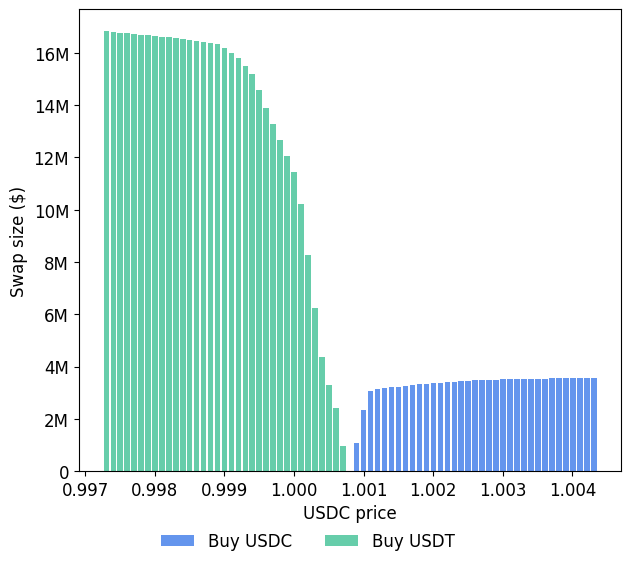

In [134]:
import datetime

dfp = pd.read_parquet('./data/Uniswap/hourly_liquidity_pricecentered_full.parquet')

def tick_to_sqrtP(tick: int) -> float:
    return 1.0001 ** (tick / 2)

def build_L_per_tick_interval(snapshot: pd.DataFrame) -> pd.Series:
    """
    Returns a Series indexed by tickLower giving L for interval [tickLower, tickLower+1)
    If your intervals are wider than 1 tick, this expands them.
    """
    rows = []
    for tl, tu, L in snapshot[['tickLower','tickUpper','active_liquidity_L']].itertuples(index=False):
        # expand interval into 1-tick pieces
        for t in range(int(tl), int(tu)):
            rows.append((t, L))
    s = pd.Series(dict(rows))
    # if multiple entries per tick (shouldn't happen), sum them
    return s.groupby(level=0).sum().sort_index()

def swap_size_curve(dip: pd.DataFrame, k_max=50, fee=0.0, tick_step=1):
    """
    Returns a dataframe with required amount_in to move +/-k ticks from current poolTick.
    fee: pool fee as fraction (e.g. 0.0001, 0.0005, 0.003). Applied as amount_in / (1-fee).
    """
    # choose one timestamp snapshot (latest)
    ts = datetime.datetime(2026,1,27, 23,tzinfo=datetime.timezone.utc)
    snap = dip[dip['hour'] == ts].copy()

    # snap = snap.query('tickLower >= -@window and tickUpper <= @window')  
    cur_tick = int(snap['poolTick'].iloc[0])

    # liquidity per 1-tick interval
    L_by_tick = build_L_per_tick_interval(snap)

    # helper: get L for interval [t, t+1)
    def L_interval(t):
        return float(L_by_tick.loc[t])  # raises if missing

    out = []
    amt_up_token1 = 0.0   # token1 in (price up)
    amt_down_token0 = 0.0 # token0 in (price down)

    for k in range(1, k_max + 1):
        # ---- move UP by tick_step (repeat k times)
        t_up_from = cur_tick + (k-1)*tick_step
        t_up_to   = cur_tick + k*tick_step

        # sum per 1-tick substep if tick_step > 1
        delta1 = 0.0
        for t in range(t_up_from, t_up_to):
            L = L_interval(t)
            sa = tick_to_sqrtP(t)
            sb = tick_to_sqrtP(t+1)
            delta1 += L * (sb - sa)
        amt_up_token1 += delta1

        # ---- move DOWN by tick_step (repeat k times)
        # crossing intervals [cur_tick-1,cur_tick), [cur_tick-2,cur_tick-1), ...
        t_dn_from = cur_tick - (k-1)*tick_step
        t_dn_to   = cur_tick - k*tick_step

        delta0 = 0.0
        for t in range(t_dn_to, t_dn_from):  # e.g. t = cur_tick-k ... cur_tick-1
            L = L_interval(t)  # interval [t, t+1) is active when moving down across it
            sa = tick_to_sqrtP(t+1)  # start at higher tick boundary
            sb = tick_to_sqrtP(t)    # end at lower tick boundary
            delta0 += L * (1.0/sb - 1.0/sa)
        amt_down_token0 += delta0

        # apply fee to amount_in (simplified: divides by (1-fee))
        up_in  = amt_up_token1 / (1.0 - fee) if fee else amt_up_token1
        dn_in  = amt_down_token0 / (1.0 - fee) if fee else amt_down_token0

        out.append({
            "k_ticks": k*tick_step,
            "token1_in_to_move_up": up_in,
            "token0_in_to_move_down": dn_in,
            "tick_up": cur_tick + k*tick_step,
            "tick_down": cur_tick - k*tick_step,
        })

    return pd.DataFrame(out), cur_tick, ts

# ---- run + plot
curve, cur_tick, ts = swap_size_curve(dfp, k_max=35, fee=0.0, tick_step=1)

fig, ax = plt.subplots(1,1,figsize=(7,6))
ax.bar(1.0001 ** curve["tick_up"], curve["token1_in_to_move_up"] / 1e6, width = 0.0001*0.8, color = 'cornflowerblue', label="Buy USDC")
ax.bar(1.0001 ** curve["tick_down"], curve["token0_in_to_move_down"] / 1e6, width = 0.0001*0.8,color = 'mediumaquamarine', label="Buy USDT")
# ax.xaxis.set_major_formatter(FuncFormatter(human_format))
ax.yaxis.set_major_formatter(FuncFormatter(human_format))
# ax.ticklabel_format(style='plain', useOffset=False)
ax.set_xlabel("USDC price", fontsize = 12)
ax.tick_params(labelsize = 12)
ax.set_ylabel("Swap size ($)", fontsize = 12)
ax.legend(ncols = 2, frameon = False, bbox_to_anchor = (.72, -0.1), fontsize = 12)
plt.savefig('./swap_size_impact.png', dpi = 300, transparent = True, bbox_inches = 'tight');